In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of policyholders in our dataset
n_samples = 2000

# Create the DataFrame
df = pd.DataFrame({
    'policy_id': range(1, n_samples + 1),
    # Normally distributed data (e.g., customer satisfaction)
    'satisfaction_score': np.random.normal(loc=7.5, scale=1.5, size=n_samples).clip(0, 10),
    # Right-skewed data (e.g., claim amounts) - very common!
    'claim_amount': np.random.lognormal(mean=8, sigma=0.8, size=n_samples).round(2),
    # Poisson-distributed data (e.g., number of support calls)
    'support_calls_last_year': np.random.poisson(lam=2, size=n_samples),
    # Categorical data for hypothesis testing
    'province': np.random.choice(['Gauteng', 'Western Cape', 'KZN'], size=n_samples, p=[0.5, 0.3, 0.2]),
    'gender': np.random.choice(['Male', 'Female'], size=n_samples),
    'has_anti_theft_device': np.random.choice([True, False], size=n_samples, p=[0.4, 0.6])
})

print("--- Synthetic Data Generated ---")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"Data types:\n{df.dtypes}")


--- Synthetic Data Generated ---
   policy_id  satisfaction_score  claim_amount  support_calls_last_year  \
0          1            8.245071       1736.90                        1   
1          2            7.292604       2655.49                        3   
2          3            8.471533       1581.40                        2   
3          4            9.784545       2330.02                        0   
4          5            7.148770        655.31                        2   

       province  gender  has_anti_theft_device  
0           KZN  Female                  False  
1       Gauteng    Male                  False  
2           KZN  Female                  False  
3  Western Cape    Male                  False  
4       Gauteng  Female                   True  

Dataset shape: (2000, 7)
Data types:
policy_id                    int64
satisfaction_score         float64
claim_amount               float64
support_calls_last_year      int64
province                    object
gender   

# Engineer Relationships in the Data

To make our hypothesis tests meaningful, we'll introduce some realistic relationships in the data:


In [6]:
# 1. For ANOVA: Make claim amounts in Gauteng slightly higher on average
df.loc[df['province'] == 'Gauteng', 'claim_amount'] *= 1.15

# 2. For T-test: Make claim amounts for Males slightly higher on average
df.loc[df['gender'] == 'Male', 'claim_amount'] *= 1.05

# 3. For Chi-Squared: Create a dependency between device and having a claim
# People with a device are less likely to have a claim
claim_probability = np.where(df['has_anti_theft_device'], 0.10, 0.20)  # 10% vs 20%
df['had_claim'] = (np.random.rand(n_samples) < claim_probability)

print("Data engineering complete!")
print(f"Average claim by province:")
print(df.groupby('province')['claim_amount'].mean().round(2))
print(f"\nAverage claim by gender:")
print(df.groupby('gender')['claim_amount'].mean().round(2))
print(f"\nClaim rates by anti-theft device:")
print(df.groupby('has_anti_theft_device')['had_claim'].mean().round(3))


Data engineering complete!
Average claim by province:
province
Gauteng         4942.45
KZN             4162.75
Western Cape    4079.00
Name: claim_amount, dtype: float64

Average claim by gender:
gender
Female    4453.72
Male      4613.88
Name: claim_amount, dtype: float64

Claim rates by anti-theft device:
has_anti_theft_device
False    0.194
True     0.085
Name: had_claim, dtype: float64


# Part 1: Exploring Statistical Distributions

Let's explore the different types of statistical distributions in our dataset and understand their characteristics through visualization.

In [7]:
# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')


# 1. Normal Distribution (Bell Curve)

Customer satisfaction scores typically follow a normal distribution. Let's visualize this:


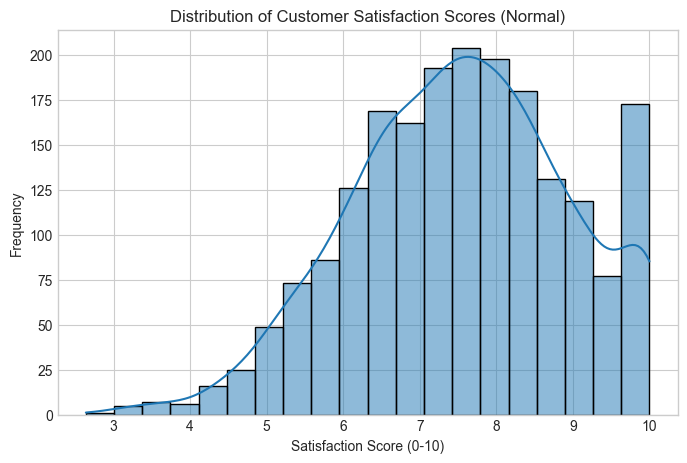

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df['satisfaction_score'], kde=True, bins=20)
plt.title('Distribution of Customer Satisfaction Scores (Normal)')
plt.xlabel('Satisfaction Score (0-10)')
plt.ylabel('Frequency')
plt.show()


# 2. Right-Skewed Distribution (Financial Data)

Claim amounts typically follow a right-skewed (log-normal) distribution, which is very common in financial data:

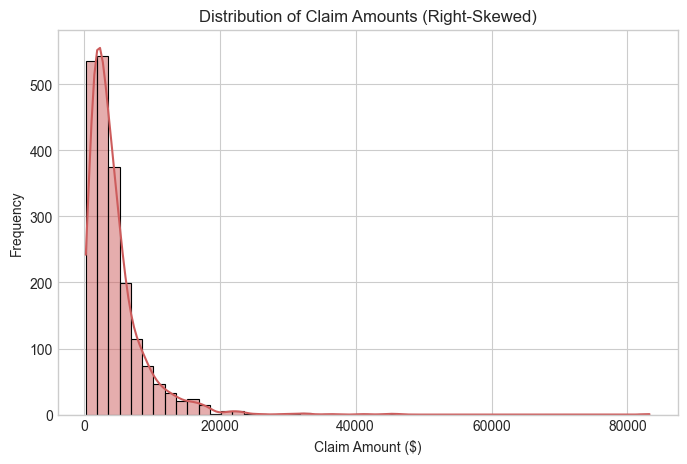

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['claim_amount'], kde=True, bins=50, color='indianred')
plt.title('Distribution of Claim Amounts (Right-Skewed)')
plt.xlabel('Claim Amount ($)')
plt.ylabel('Frequency')
plt.show()


# 3. Poisson Distribution (Count Data)

The number of support calls follows a Poisson distribution, which is ideal for modeling count data:

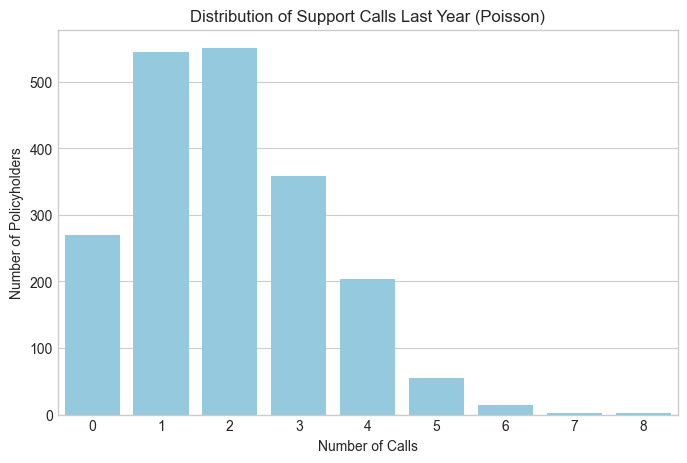

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x=df['support_calls_last_year'], color='skyblue')
plt.title('Distribution of Support Calls Last Year (Poisson)')
plt.xlabel('Number of Calls')
plt.ylabel('Number of Policyholders')
plt.show()


# Part 2: Hypothesis Testing

Now let's use statistical hypothesis tests to answer important business questions. We'll perform three types of tests:

1. Independent T-test - Compare means between two groups
2. ANOVA - Compare means across multiple groups  
3. Chi-Squared test - Test for associations between categorical variables



# 1. Independent T-test

Business Question: Is there a difference in average claim amount between genders?

Hypotheses:
- H₀ (Null): The mean claim amount is the same for Males and Females
- H₁ (Alternative): The mean claim amount is different for Males and Females


In [10]:
# Separate claim amounts by gender
male_claims = df[df['gender'] == 'Male']['claim_amount']
female_claims = df[df['gender'] == 'Female']['claim_amount']

# Perform the t-test
t_stat, p_value_ttest = stats.ttest_ind(male_claims, female_claims)

print("--- T-test Results ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value_ttest:.4f}")
print(f"Alpha level: 0.05")
print()

# Interpret the result
if p_value_ttest < 0.05:
    print("✅ Result: Reject the null hypothesis.")
    print("   The difference in claim amounts between genders is statistically significant.")
else:
    print("❌ Result: Fail to reject the null hypothesis.")
    print("   The difference in claim amounts between genders is not statistically significant.")

print(f"\nDescriptive Statistics:")
print(f"Male average claim: ${male_claims.mean():.2f}")
print(f"Female average claim: ${female_claims.mean():.2f}")
print(f"Difference: ${male_claims.mean() - female_claims.mean():.2f}")


--- T-test Results ---
T-statistic: 0.7835
P-value: 0.4334
Alpha level: 0.05

❌ Result: Fail to reject the null hypothesis.
   The difference in claim amounts between genders is not statistically significant.

Descriptive Statistics:
Male average claim: $4613.88
Female average claim: $4453.72
Difference: $160.16


# 2. ANOVA (Analysis of Variance)

Business Question: Is there a difference in average claim amount across provinces?

Hypotheses:
- H₀ (Null): The mean claim amount is the same for all provinces
- H₁ (Alternative): At least one province has a different mean claim amount


In [11]:
# Separate claim amounts by province
gauteng_claims = df[df['province'] == 'Gauteng']['claim_amount']
wc_claims = df[df['province'] == 'Western Cape']['claim_amount']
kzn_claims = df[df['province'] == 'KZN']['claim_amount']

# Perform the ANOVA test
f_stat, p_value_anova = stats.f_oneway(gauteng_claims, wc_claims, kzn_claims)

print("--- ANOVA Results ---")
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value_anova:.4f}")
print(f"Alpha level: 0.05")
print()

# Interpret the result
if p_value_anova < 0.05:
    print("✅ Result: Reject the null hypothesis.")
    print("   There is a significant difference in claim amounts between provinces.")
else:
    print("❌ Result: Fail to reject the null hypothesis.")
    print("   No significant difference in claim amounts between provinces.")

print(f"\nDescriptive Statistics by Province:")
province_stats = df.groupby('province')['claim_amount'].agg(['mean', 'std', 'count']).round(2)
print(province_stats)


--- ANOVA Results ---
F-statistic: 8.3196
P-value: 0.0003
Alpha level: 0.05

✅ Result: Reject the null hypothesis.
   There is a significant difference in claim amounts between provinces.

Descriptive Statistics by Province:
                 mean      std  count
province                             
Gauteng       4942.45  5296.92   1008
KZN           4162.75  3557.23    415
Western Cape  4079.00  3701.13    577


# 3. Chi-Squared Test

Business Question: Is there an association between having an anti-theft device and having a claim?

Hypotheses:
- H₀ (Null): There is no association between having a device and having a claim (variables are independent)
- H₁ (Alternative): There is an association between the two variables (variables are dependent)


In [12]:
# Create a contingency table (crosstab)
contingency_table = pd.crosstab(df['has_anti_theft_device'], df['had_claim'])
print("Contingency Table:")
print(contingency_table)
print()

# Perform the Chi-Squared test
chi2_stat, p_value_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print("--- Chi-Squared Test Results ---")
print(f"Chi-Squared Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value_chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"Alpha level: 0.05")
print()

# Interpret the result
if p_value_chi2 < 0.05:
    print("✅ Result: Reject the null hypothesis.")
    print("   There is a significant association between having an anti-theft device and claims.")
else:
    print("❌ Result: Fail to reject the null hypothesis.")
    print("   There is no significant association between the variables.")

# Show the expected frequencies
print(f"\nExpected Frequencies:")
expected_df = pd.DataFrame(expected, 
                          index=contingency_table.index, 
                          columns=contingency_table.columns)
print(expected_df.round(2))


Contingency Table:
had_claim              False  True 
has_anti_theft_device              
False                    970    233
True                     729     68

--- Chi-Squared Test Results ---
Chi-Squared Statistic: 43.1869
P-value: 0.0000
Degrees of Freedom: 1
Alpha level: 0.05

✅ Result: Reject the null hypothesis.
   There is a significant association between having an anti-theft device and claims.

Expected Frequencies:
had_claim                False   True 
has_anti_theft_device                 
False                  1021.95  181.05
True                    677.05  119.95


# Summary

This notebook demonstrated key statistical concepts:

# Distributions Explored:
1. Normal Distribution - Customer satisfaction scores (bell curve)
2. Right-Skewed Distribution - Claim amounts (log-normal, common in financial data)
3. Poisson Distribution - Support calls (count data)

# Hypothesis Tests Performed:
1. T-test - Compared claim amounts between genders
2. ANOVA - Compared claim amounts across provinces
3. Chi-Squared - Tested association between anti-theft devices and claims

# Key Takeaways:
- Understanding data distributions helps choose appropriate statistical tests
- P-values < 0.05 indicate statistical significance (reject null hypothesis)
- Always interpret results in business context
- Visualizations help communicate findings effectively

The engineered relationships in our synthetic data should have produced significant results for all three tests, demonstrating how these statistical tools can uncover meaningful business insights.
